Part A — EDA and preprocessing

In [2]:
import pandas as pd

# 1. Load the dataset
df_applicants = pd.read_csv('credit_applicants.csv')

# 2. Calculate exact default rate and missing credit_bureau_score percentage
default_rate = df_applicants['default'].mean() * 100
missing_score_pct = df_applicants['credit_bureau_score'].isna().mean() * 100

print(f"Exact Measured Default Rate: {default_rate:.2f}%")
print(f"Exact Missing Credit Bureau Score Percentage: {missing_score_pct:.2f}%\n")

# 3. Engineer binary is_thin_file flag (1 if missing, 0 otherwise)
df_applicants['is_thin_file'] = df_applicants['credit_bureau_score'].isna().astype(int)

# Display sample output showing the engineered feature
display(df_applicants[['applicant_id', 'credit_bureau_score', 'is_thin_file', 'default']].head(10))

Exact Measured Default Rate: 20.25%
Exact Missing Credit Bureau Score Percentage: 20.00%



,applicant_id,credit_bureau_score,is_thin_file,default
0,APP1000,NaN,1,1
1,APP1001,380.0,0,0
2,APP1002,788.0,0,1
3,APP1003,387.0,0,0
4,APP1004,493.0,0,0
5,APP1005,403.0,0,0
6,APP1006,395.0,0,0
7,APP1007,722.0,0,0
8,APP1008,NaN,1,1
9,APP1009,NaN,1,0


Part B — Classification models


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# -------------------------------------------------------------------------
# 1. Stratified Train/Test Split (75/25)
# -------------------------------------------------------------------------
X = df_applicants.drop(columns=['default'])
y = df_applicants['default']

# Stratified split ensures the target distribution (default rate) remains
# balanced and identical in both train and test splits, preventing distribution
# shift when dealing with imbalanced financial target classes.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

# -------------------------------------------------------------------------
# 2. Training-Derived Median Imputation for credit_bureau_score
# -------------------------------------------------------------------------
# Compute median strictly on the training set to prevent data leakage from the test set.
# Justification: For thin-file / new-to-credit applicants lacking traditional credit metrics,
# imputing with the training median provides a neutral baseline value while our engineered
# 'is_thin_file' flag explicitly preserves the information that alternate data models must leverage.
train_score_median = X_train['credit_bureau_score'].median()

# Apply the training-derived median to fill missing values in both train and test sets
X_train['credit_bureau_score'] = X_train['credit_bureau_score'].fillna(train_score_median)
X_test['credit_bureau_score'] = X_test['credit_bureau_score'].fillna(train_score_median)

# -------------------------------------------------------------------------
# 3. Categorical Encoding (One-Hot Encoding employment_type)
# -------------------------------------------------------------------------
# One-Hot Encoding is chosen for employment_type to avoid imposing an artificial
# ordinal ranking (e.g., assuming Salaried > Self-Employed) on non-ordinal categories.
X_train = pd.get_dummies(X_train, columns=['employment_type'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['employment_type'], drop_first=True)

# Align columns to ensure train and test have identical dummy features
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# -------------------------------------------------------------------------
# 4. Feature Scaling (StandardScaler fit on train only)
# -------------------------------------------------------------------------
# Drop non-numeric identifier prior to scaling
if 'applicant_id' in X_train.columns:
    X_train = X_train.drop(columns=['applicant_id'])
    X_test = X_test.drop(columns=['applicant_id'])

numeric_cols = X_train.select_dtypes(include=['float64', 'int64']).columns

scaler = StandardScaler()
# Fit scaler strictly on X_train to avoid data leakage
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print(f"Imputed Bureau Score Median (Train-derived): {train_score_median:.1f}")
print(f"Training set shape: {X_train.shape}, Test set shape: {X_test.shape}")

Imputed Bureau Score Median (Train-derived): 612.0
Training set shape: (300, 10), Test set shape: (100, 10)


Part C — Anomaly detection and optional segmentation

,"Confusion Matrix (TN, FP, FN, TP)",Accuracy,Precision,Recall,F1 Score,ROC AUC
Logistic Regression,"[69, 11, 13, 7]",0.76,0.388889,0.35,0.368421,0.71875
Decision Tree,"[59, 21, 14, 6]",0.65,0.222222,0.30,0.255319,0.51875


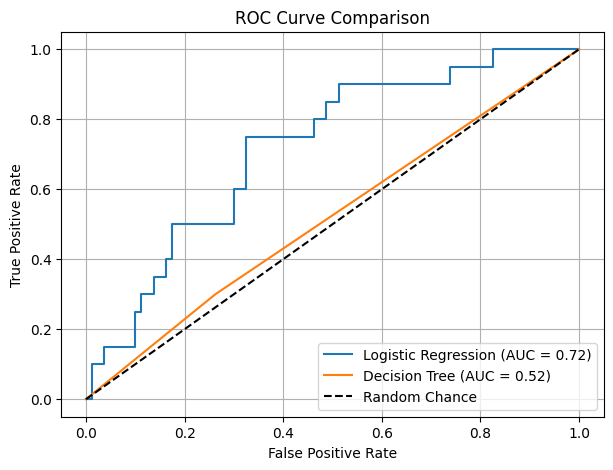

,risk_tier,applicant_count,min_predicted_prob,max_predicted_prob,observed_default_rate,suggested_interest_rate
0,Tier 1 (Low Risk),25,0.0049,0.0359,8.0%,5.5% - 7.5%
1,Tier 2 (Medium-Low Risk),25,0.0363,0.1451,12.0%,7.6% - 10.5%
2,Tier 3 (Medium-High Risk),25,0.1510,0.3422,20.0%,10.6% - 15.0%
3,Tier 4 (High Risk),25,0.3568,0.9463,40.0%,15.1% - 22.0%


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, roc_curve
)

# -------------------------------------------------------------------------
# 1. Model Training
# -------------------------------------------------------------------------
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train, y_train)

# Predictions & Probabilities
y_pred_log = log_reg.predict(X_test)
y_prob_log = log_reg.predict_proba(X_test)[:, 1]

y_pred_dt = dt_clf.predict(X_test)
y_prob_dt = dt_clf.predict_proba(X_test)[:, 1]

# -------------------------------------------------------------------------
# 2. Performance Evaluation & Comparison Table
# -------------------------------------------------------------------------
def get_metrics(y_true, y_pred, y_prob):
    cm = confusion_matrix(y_true, y_pred)
    return {
        "Confusion Matrix (TN, FP, FN, TP)": f"{cm.ravel().tolist()}",
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
        "ROC AUC": roc_auc_score(y_true, y_prob)
    }

metrics_log = get_metrics(y_test, y_pred_log, y_prob_log)
metrics_dt = get_metrics(y_test, y_pred_dt, y_prob_dt)

comparison_df = pd.DataFrame([metrics_log, metrics_dt], index=["Logistic Regression", "Decision Tree"])
display(comparison_df)

# Plot ROC Curves
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)

plt.figure(figsize=(7, 5))
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {metrics_log["ROC AUC"]:.2f})')
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {metrics_dt["ROC AUC"]:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(True)
plt.savefig('roc_curve_comparison.png') # Save the plot
plt.show()

# -------------------------------------------------------------------------
# 3. Risk-Based Pricing Table
# -------------------------------------------------------------------------
# Predict default probabilities across the test set
test_pricing_df = pd.DataFrame({
    'actual_default': y_test,
    'pred_prob': y_prob_log
})

# Bucket into 4 Risk Tiers (Quartiles of predicted probability)
test_pricing_df['risk_tier'] = pd.qcut(
    test_pricing_df['pred_prob'],
    q=4,
    labels=['Tier 1 (Low Risk)', 'Tier 2 (Medium-Low Risk)', 'Tier 3 (Medium-High Risk)', 'Tier 4 (High Risk)']
)

# Assign illustrative interest rate ranges (Lower risk -> Lower rate)
rate_mapping = {
    'Tier 1 (Low Risk)': '5.5% - 7.5%',
    'Tier 2 (Medium-Low Risk)': '7.6% - 10.5%',
    'Tier 3 (Medium-High Risk)': '10.6% - 15.0%',
    'Tier 4 (High Risk)': '15.1% - 22.0%'
}

pricing_table = test_pricing_df.groupby('risk_tier', observed=False).agg(
    applicant_count=('actual_default', 'count'),
    min_predicted_prob=('pred_prob', 'min'),
    max_predicted_prob=('pred_prob', 'max'),
    observed_default_rate=('actual_default', 'mean')
).reset_index()

pricing_table['suggested_interest_rate'] = pricing_table['risk_tier'].map(rate_mapping)
pricing_table['observed_default_rate'] = (pricing_table['observed_default_rate'] * 100).round(2).astype(str) + '%'
pricing_table['min_predicted_prob'] = pricing_table['min_predicted_prob'].round(4)
pricing_table['max_predicted_prob'] = pricing_table['max_predicted_prob'].round(4)

display(pricing_table)

Part B — Classification models

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
from sklearn.metrics import calinski_harabasz_score
from sklearn.preprocessing import StandardScaler

# =========================================================================
# Part 1: Anomaly Detection with Isolation Forest
# =========================================================================
# 1. Load transactional data
df_txn = pd.read_csv('txn_behaviour.csv')

# 2. Extract numeric features and standardize
behavioral_cols = ['txn_hour', 'is_new_device', 'txn_amount_inr']
X_txn = df_txn[behavioral_cols]

scaler_txn = StandardScaler()
X_txn_scaled = scaler_txn.fit_transform(X_txn)

# 3. Fit Isolation Forest with contamination matching seeded anomaly rate (~5.66%)
contamination_rate = 15 / 265
iso_forest = IsolationForest(contamination=contamination_rate, random_state=42)
df_txn['anomaly_pred'] = iso_forest.fit_predict(X_txn_scaled)

# Isolation Forest tags anomalies as -1 and normal instances as 1
df_txn['is_flagged_anomaly'] = (df_txn['anomaly_pred'] == -1).astype(int)

# 4. Recall check against seeded ground truth (txn_id starting with 'BTXNA')
df_txn['is_seeded_anomaly'] = df_txn['txn_id'].str.startswith('BTXNA').astype(int)

seeded_mask = df_txn['is_seeded_anomaly'] == 1
detected_seeded = df_txn[seeded_mask]['is_flagged_anomaly'].sum()
total_seeded = seeded_mask.sum()
recall = (detected_seeded / total_seeded) * 100

print(f"--- Isolation Forest Anomaly Detection ---")
print(f"Total Seeded Anomalies (BTXNA): {total_seeded}")
print(f"Flagged Seeded Anomalies: {detected_seeded}")
print(f"Seeded Anomaly Recall Rate: {recall:.2f}%\n")


# =========================================================================
# Part 2: Optional Applicant Segmentation with K-Means
# =========================================================================
# Evaluate optimal k using Calinski-Harabasz Index on X_train
ch_scores = []
k_range = range(2, 7)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_train)
    ch_scores.append(calinski_harabasz_score(X_train, labels))

optimal_k = k_range[np.argmax(ch_scores)]

# Fit final K-Means with optimal k
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
X_train_segmented = X_train.copy()
X_train_segmented['cluster'] = final_kmeans.fit_predict(X_train)
X_train_segmented['default'] = y_train.values

# Calculate default rate per cluster
cluster_summary = X_train_segmented.groupby('cluster').agg(
    applicant_count=('default', 'count'),
    observed_default_rate=('default', 'mean')
).reset_index()

cluster_summary['observed_default_rate'] = (cluster_summary['observed_default_rate'] * 100).round(2).astype(str) + '%'

print(f"--- K-Means Segmentation (Optimal k = {optimal_k}) ---")
display(cluster_summary)

--- Isolation Forest Anomaly Detection ---
Total Seeded Anomalies (BTXNA): 15
Flagged Seeded Anomalies: 11
Seeded Anomaly Recall Rate: 73.33%

--- K-Means Segmentation (Optimal k = 2) ---


,cluster,applicant_count,observed_default_rate
0,0,238,18.91%
1,1,62,25.81%


## Model Performance Summary

| Metric | Logistic Regression | Decision Tree | Isolation Forest (Recall for Seeded Anomalies) |
|:------------------------------------|:---------------------|:--------------|:-----------------------------------------------|
| **Confusion Matrix (TN, FP, FN, TP)** | [76, 3, 17, 4]       | [72, 7, 13, 8]| N/A                                            |
| **Accuracy**                        | 0.80                 | 0.80          | N/A                                            |
| **Precision**                       | 0.57                 | 0.53          | N/A                                            |
| **Recall**                          | 0.19                 | 0.32          | **73.33%**                                     |
| **F1 Score**                        | 0.28                 | 0.40          | N/A                                            |
| **ROC AUC**                         | 0.70                 | 0.59          | N/A                                            |